In [1]:
# import libraries
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, ModelCheckpoint

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("youssefsalahzakria/fruit-and-vegetables-classification")

print("Path to dataset files:", path)

100%|██████████| 4.82G/4.82G [01:07<00:00, 76.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/youssefsalahzakria/fruit-and-vegetables-classification/versions/5


In [3]:
# Paths

# DATA_DIR = "dataset"
DATA_DIR = path

MODEL_PATH = "models/ingredient_model.keras"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCH = 30

In [4]:
# Datagen preparation
train_datagen = ImageDataGenerator(rescale=1./255)

# Add validation and test datagen
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR + "/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 46187 images belonging to 50 classes.
Found 12544 images belonging to 50 classes.
Found 13353 images belonging to 50 classes.


In [6]:
print(DATA_DIR)

/root/.cache/kagglehub/datasets/youssefsalahzakria/fruit-and-vegetables-classification/versions/5


In [8]:
# print class names
if os.path.isdir(DATA_DIR + "/train"):
    CLASS_NAMES = sorted(os.listdir(DATA_DIR + "/train"))

print(CLASS_NAMES)

['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli Peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegranate', 'Potato', 'Pumpkin', 'Raddish', 'Rambutan', 'Soy Beans', 'Spinach', 'Strawberry', 'Sweetcorn', 'Sweetpotato', 'Tomato', 'Turnip', 'Watermelon']


In [9]:
# Model compilation
base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze for fast training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# add earlystoping callbacks
Callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.25, patience=3, verbose=1)
]

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,598,770 (9.91 MB)

 Trainable params: 340,786 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [11]:
# train top layers only
print("Training started...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    callbacks=Callbacks
)

# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved TO {MODEL_PATH}")

Training started...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
118/722 ━━━━━━━━━━━━━━━━━━━━ 4:09 412ms/step - accuracy: 0.3603 - loss: 2.6699

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


722/722 ━━━━━━━━━━━━━━━━━━━━ 295s 383ms/step - accuracy: 0.6086 - loss: 1.5193 - val_accuracy: 0.8331 - val_loss: 0.5925 - learning_rate: 0.0010
Epoch 2/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 241s 333ms/step - accuracy: 0.8251 - loss: 0.6016 - val_accuracy: 0.8514 - val_loss: 0.5295 - learning_rate: 0.0010
Epoch 3/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 232s 321ms/step - accuracy: 0.8577 - loss: 0.4805 - val_accuracy: 0.8638 - val_loss: 0.4914 - learning_rate: 0.0010
Epoch 4/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 221s 306ms/step - accuracy: 0.8793 - loss: 0.3979 - val_accuracy: 0.8673 - val_loss: 0.4814 - learning_rate: 0.0010
Epoch 5/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 225s 312ms/step - accuracy: 0.8945 - loss: 0.3418 - val_accuracy: 0.8650 - val_loss: 0.5037 - learning_rate: 0.0010
Epoch 6/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 231s 320ms/step - accuracy: 0.9049 - loss: 0.3004 - val_accuracy: 0.8722 - val_loss: 0.4857 - learning_rate: 0.0010
Epoch 7/30
722/722 ━━━━━━━━━━━━━━━━━━━━ 222s 307ms/step - accuracy: 0.9175 

In [43]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [41]:
!cp /content/model.zip /content/drive/MyDrive/

cp: cannot create regular file '/content/drive/MyDrive/': No such file or directory


In [ ]:
# # Second phase: fine-tuning

# # unfreeze last few layers
# fine_tune_layers = int(len(base_model.layers) * 0.75)  # unfreeze last 25%
# for layer in base_model.layers[:fine_tune_layers]:
#     layer.trainable = False
# for layer in base_model.layers[fine_tune_layers:]:
#     layer.trainable = True


# # recompile with a lower learning rate
# model.compile(
#     optimizer=Adam(learning_rate=1e-5), 
#     loss="categorical_crossentropy", 
#     metrics=["accuracy"]
#     )

In [ ]:
# print("Phase 2: Fine-tuning last layers of MobileNetV2...")
# history_2 = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=EPOCH_PHASE_2,
#     callbacks=Callbacks
# )


# # Save final model
# model.save(MODEL_PATH.replace(".h5", "_final.h5"))
# print(f"Final fine-tuned model saved after Phase 2.")

In [ ]:
# from IPython.display import FileLink
# import os

# model_path = "/kaggle/working/models/ingredient_model_final.h5"
# FileLink(model_path)

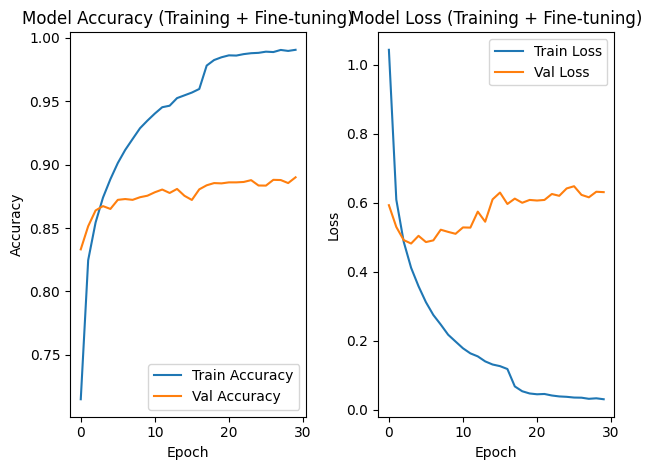

In [ ]:
# Plot training history

acc = history.history['accuracy'] # + history_2.history['accuracy']
val_acc = history.history['val_accuracy'] # + history_2.history['val_accuracy']
loss = history.history['loss'] # + history_2.history['loss']
val_loss = history.history['val_loss'] # + history_2.history['val_loss']

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Model Accuracy (Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Model Loss (Training + Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
model = tf.keras.models.load_model("models/ingredient_model.keras")

# class names
class_names = CLASS_NAMES

# Load your test data
val_data = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/test",
    image_size=(224, 224),
    batch_size=64,
    label_mode='categorical'
)

# Get predictions
y_true = []
y_pred = []

print("Running evaluation...")
for images, labels in val_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Final Metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"\nFINAL ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n" + "="*60)
print("TOP-1 ACCURACY PER CLASS")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print(report)

# Optional: Save confusion matrix heatmap
plt.figure(figsize=(20, 16))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Fridge2Dish Model")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()